In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.dummy import DummyRegressor
import joblib
from pathlib import Path
import os
import sys
import seaborn as sns
project_root = Path(os.getcwd()).parent  # Goes up from error analysis/ to project root
sys.path.insert(0, str(project_root))
from src.features import prep_features


In [30]:
X = pd.read_csv("EVAL_X_DATA_YYYYMMDD.csv")
X = prep_features(X)
model_path = Path("../models/model_v3.pkl")
with open(model_path, "rb") as f:
	model = joblib.load(f)
FEATURE_ORDER = list(model.feature_names_in_)
X = X[FEATURE_ORDER]

true_y = pd.read_csv("TEST_SET_Y.csv").squeeze()
pred_y = pd.read_csv("predictions.csv").squeeze()

residuals = pred_y - true_y

/Users/ellayakir/Documents/Documents - Ella’s MacBook Air/job search/YDATA/airbnb-rating-prediction/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/ellayakir/Documents/Documents - Ella’s MacBook Air/job search/YDATA/airbnb-rating-prediction/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/ellayakir/

### 1. Comparing Model to a Dummy Model

In [31]:
TRAINING_MEAN = 4.691 
model_rmse = root_mean_squared_error(true_y, pred_y)

dummy_preds = np.full(len(true_y), TRAINING_MEAN)
dummy_rmse = np.sqrt(mean_squared_error(true_y, dummy_preds))

print(f"Model RMSE: {model_rmse}")
print(f"Dummy RMSE: {dummy_rmse}")

Model RMSE: 0.3798602953812417
Dummy RMSE: 0.41172581232222405


### 2. Assessing Residuals

In [32]:
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)
print(f"Mean of residuals: {mean_residual}")
print(f"Standard deviation of residuals: {std_residual}")

Mean of residuals: -0.0004094850975536883
Standard deviation of residuals: 0.37986007467102817


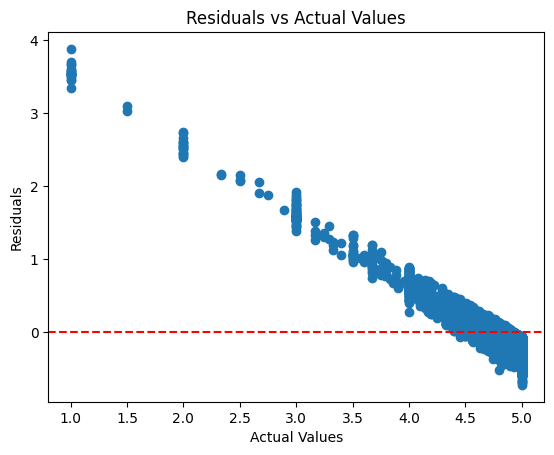

In [33]:
plt.scatter(true_y, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Actual Values')
plt.show()

In [34]:
correlation, p_value = stats.pearsonr(true_y, residuals)
print(f"Correlation between true values and residuals: {correlation:.4f}, p-value: {p_value:.4f}")

Correlation between true values and residuals: -0.9478, p-value: 0.0000


##### Residuals Analysis by True Ratings Bins

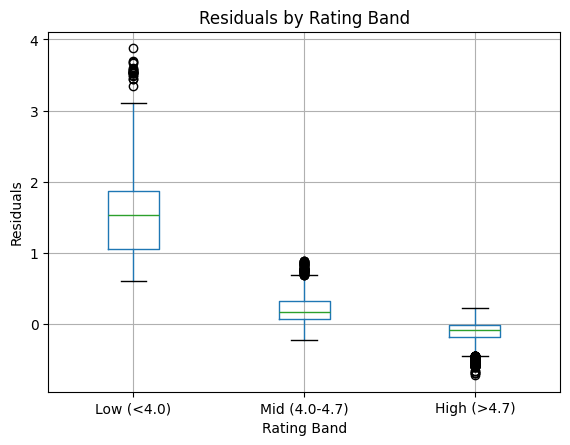

Correlation for Low (<4.0): -0.9922, Mean: 1.6672, Std: 0.8401, p-value: 0.0000
Correlation for Mid (4.0-4.7): -0.8438, Mean: 0.2082, Std: 0.2125, p-value: 0.0000
Correlation for High (>4.7): -0.6153, Mean: -0.1152, Std: 0.1498, p-value: 0.0000


In [35]:
bins   = [0, 4.0, 4.7, 5.01]
labels = ["Low (<4.0)", "Mid (4.0-4.7)", "High (>4.7)"]
rating_band = pd.cut(true_y, bins=bins, labels=labels, right=False)
residuals_by_band = pd.DataFrame({'Residuals': residuals, 'Rating Band': rating_band})
residuals_by_band.boxplot(column='Residuals', by='Rating Band')
plt.title('Residuals by Rating Band')
plt.suptitle('')
plt.xlabel('Rating Band')
plt.ylabel('Residuals')
plt.show()

for band in labels:
	band_residuals = residuals_by_band[residuals_by_band['Rating Band'] == band]['Residuals']
	mean_band_residual = np.mean(band_residuals)
	std_band_residual = np.std(band_residuals)
	correlation_band, p_value_band = stats.pearsonr(true_y[rating_band == band], band_residuals)
	print(f"Correlation for {band}: {correlation_band:.4f}, Mean: {mean_band_residual:.4f}, Std: {std_band_residual:.4f}, p-value: {p_value_band:.4f}")

### Errors by Features
Looking for prominent features that drive systematic errors (high |pearson's r|). 

In [36]:
rs = []
ps = []

for col in FEATURE_ORDER:
	correlation_feature, p_value_feature = stats.pearsonr(X[col], residuals)
	rs.append(correlation_feature), ps.append(p_value_feature)
	print(f"Correlation between {col} and residuals: {correlation_feature:.4f}, p-value: {p_value_feature:.4f}")
print()
rs = [abs(r) for r in rs]
feature_importance = model.feature_importances_
features_df = pd.DataFrame({'Feature': FEATURE_ORDER, 'Importance': feature_importance, 'Absoulute Correlation with Residuals': rs, 'P-value': ps})
mask = (features_df['P-value'] < 0.05) & (features_df['Absoulute Correlation with Residuals'] > 0.1) & (features_df['Importance'] > 0.1)
print(features_df.loc[mask])

Correlation between accommodates and residuals: -0.0193, p-value: 0.1105
Correlation between bathrooms and residuals: 0.0162, p-value: 0.1822
Correlation between bedrooms and residuals: -0.0216, p-value: 0.0746
Correlation between beds and residuals: -0.0155, p-value: 0.2011
Correlation between room_ratio and residuals: 0.0382, p-value: 0.0016
Correlation between host_response_rate and residuals: -0.0143, p-value: 0.2373
Correlation between host_acceptance_rate and residuals: 0.0255, p-value: 0.0353
Correlation between is_superhost and residuals: -0.0237, p-value: 0.0507
Correlation between host_days_log and residuals: -0.0049, p-value: 0.6864
Correlation between minimum_nights and residuals: 0.0024, p-value: 0.8437
Correlation between instant_bookable and residuals: 0.0731, p-value: 0.0000
Correlation between has_description and residuals: -0.0056, p-value: 0.6467
Correlation between desc_length and residuals: -0.0426, p-value: 0.0004
Correlation between has_host_about and residuals: 

No individual feature drives the overwhelming correlation, including the most important features.
Let's examine the correlation of each feature with the true rating: 

In [37]:
print("\nCorrelation between features and true ratings:")
for col in FEATURE_ORDER:
    corr_with_true = X[col].corr(true_y)
    print(f"{col:30s}  r={corr_with_true:+.4f}")


Correlation between features and true ratings:
accommodates                    r=+0.0891
bathrooms                       r=+0.0330
bedrooms                        r=+0.0944
beds                            r=+0.0859
room_ratio                      r=-0.0468
host_response_rate              r=+0.0793
host_acceptance_rate            r=+0.0007
is_superhost                    r=+0.2773
host_days_log                   r=+0.1453
minimum_nights                  r=-0.0295
instant_bookable                r=-0.1686
has_description                 r=+0.0239
desc_length                     r=+0.1429
has_host_about                  r=+0.0444
response_speed                  r=+0.0133
mentions_clean                  r=+0.0041
mentions_luxury                 r=+0.0517
mentions_view                   r=-0.0061
mentions_location               r=+0.0145
mentions_modern                 r=+0.0080
has_neighborhood                r=+0.0988
name_length                     r=+0.0356


### Worst Predictions and Where to Find Them

### Distribution shift: training vs. test

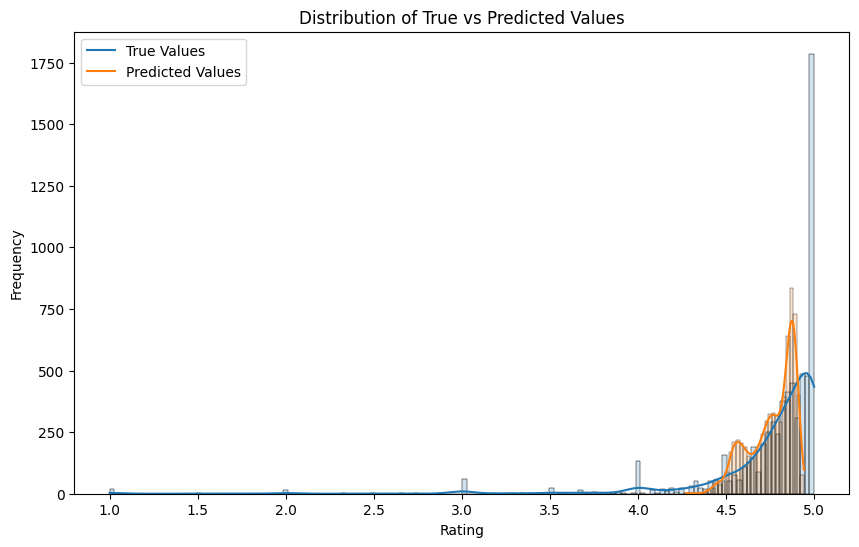

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(true_y, kde=True, alpha=0.2)
sns.histplot(pred_y, kde=True, alpha=0.2)
plt.legend(['True Values', 'Predicted Values'])
plt.title('Distribution of True vs Predicted Values')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()